<div align="center">

# Medical Document Classification — New Dataset

</div>

This notebook performs EDA and trains an XGBoost classification pipeline on the new medical document dataset.  
The pipeline is saved as `model.pkl` (bundled with its `LabelEncoder`) for direct use in the MediSort desktop app.

**Categories:** `prescription`, `lab_report`, `discharge_summary`, `medical_bill`, `insurance_claim`, `referral_letter`, `other`


## 1. Imports

In [1]:
import ast
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
print("All imports OK")


All imports OK


## 2. Load Dataset

In [2]:
path = '/kaggle/input/datasets/adwaittagalpallewar/updataed-docx/medical_documents_dataset (1).csv'
data = pd.read_csv(path)

print(f"Shape     : {data.shape}")
print(f"Columns   : {list(data.columns)}")
print(f"Dtypes    :\n{data.dtypes}")
print(f"\nNull values:\n{data.isna().sum()}")
data.head(3)

Shape     : (4900, 4)
Columns   : ['ocr_lines', 'text', 'file_format', 'label']
Dtypes    :
ocr_lines      object
text           object
file_format    object
label          object
dtype: object

Null values:
ocr_lines      0
text           0
file_format    0
label          0
dtype: int64


,ocr_lines,text,file_format,label
0,"['Manipal Hospitals', '', 'PAST MEDICAL HISTOR...",Manipal Hospitals PAST MEDICAL HISTORY RECORD...,jpg,other
1,"['Suburban Diagnostics', 'Referréd by: AIIMS',...",Suburban Diagnostics Referréd by: AIIMS LABOR...,pdf,lab_report
2,"['PD Hinduja', 'Department of General Medicine...",PD Hinduja Department of General Medicine REF...,png,referral_letter


## 3. Exploratory Data Analysis

### 3.1 Class Distribution


Class counts:
  discharge_summary           700
  insurance_claim             700
  lab_report                  700
  medical_bill                700
  other                       700
  prescription                700
  referral_letter             700


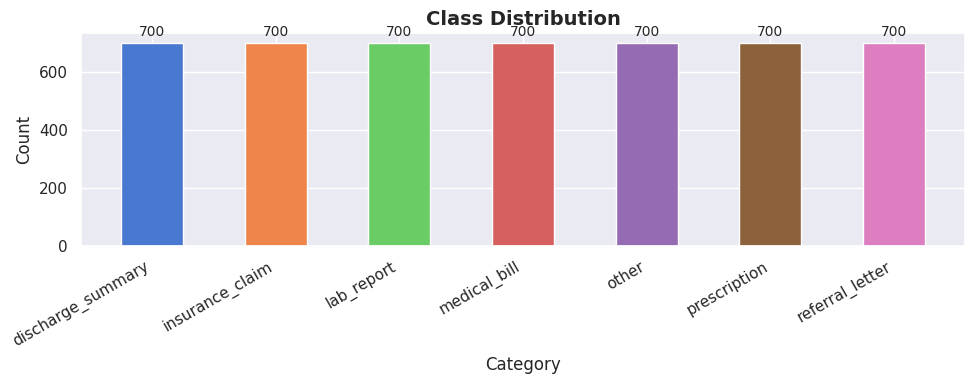

In [3]:
counts = Counter(data['label'])
print("Class counts:")
for k, v in sorted(counts.items()):
    print(f"  {k:<25} {v:>5}")

fig, ax = plt.subplots(figsize=(10, 4))
labels_sorted = sorted(counts.keys())
values_sorted = [counts[k] for k in labels_sorted]
bars = ax.bar(labels_sorted, values_sorted, width=0.5, color=sns.color_palette("muted", len(labels_sorted)))
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Class Distribution", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 3.2 File Format Distribution

File format counts: {'jpg': 1738, 'pdf': 1551, 'png': 1611}


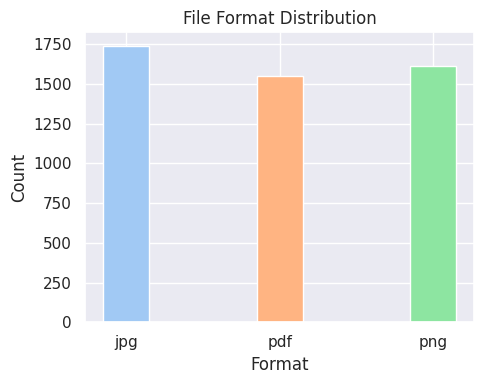

In [4]:
fmt_counts = Counter(data['file_format'])
print("File format counts:", dict(fmt_counts))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(fmt_counts.keys(), fmt_counts.values(), width=0.3, color=sns.color_palette("pastel"))
ax.set_xlabel("Format")
ax.set_ylabel("Count")
ax.set_title("File Format Distribution")
plt.tight_layout()
plt.show()


### 3.3 Parse `ocr_lines` and compute `line_count`

In [5]:
# ocr_lines is stored as a stringified Python list — parse it back
data['ocr_lines']  = data['ocr_lines'].apply(ast.literal_eval)
data['line_count'] = data['ocr_lines'].map(len)

print(f"line_count stats:\n{data['line_count'].describe().round(1)}")


line_count stats:
count    4900.0
mean       36.9
std         7.7
min        21.0
25%        31.0
50%        37.0
75%        44.0
max        53.0
Name: line_count, dtype: float64


### 3.4 Line Count Distribution

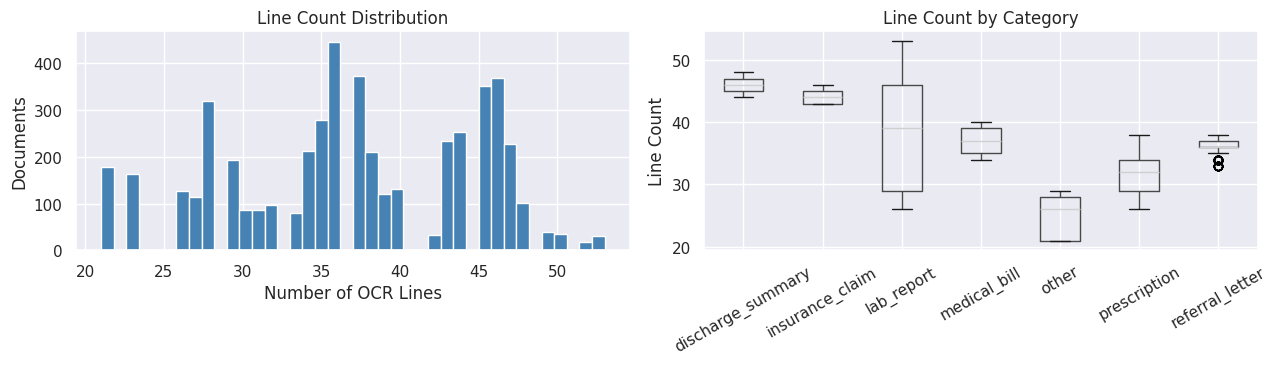

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(data['line_count'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Line Count Distribution")
axes[0].set_xlabel("Number of OCR Lines")
axes[0].set_ylabel("Documents")

# Box plot per category
data.boxplot(column='line_count', by='label', ax=axes[1], rot=30)
axes[1].set_title("Line Count by Category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Line Count")
plt.suptitle("")
plt.tight_layout()
plt.show()


### 3.5 Word Count (character count — matches training convention)

word_count stats:
count    4900.0
mean     1161.4
std       440.1
min       434.0
25%       762.0
50%      1267.0
75%      1451.0
max      2636.0
Name: word_count, dtype: float64


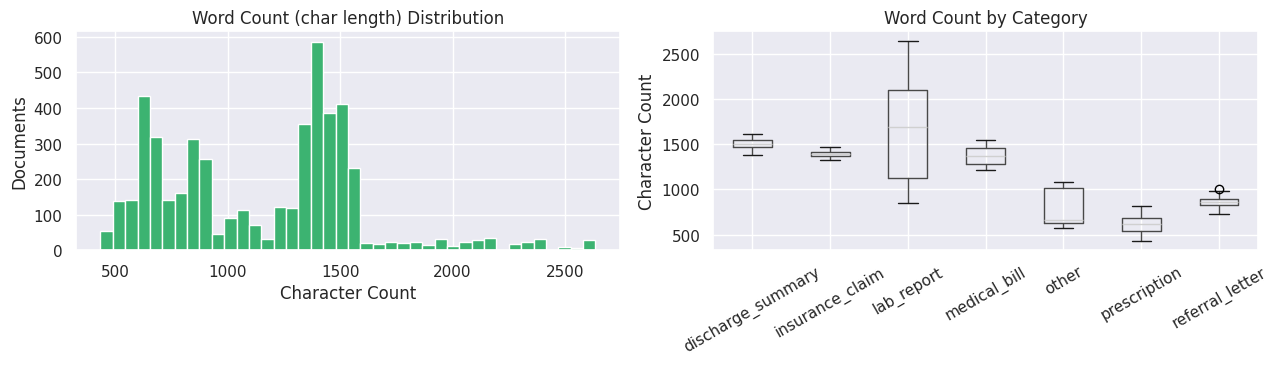

In [7]:
# word_count = len(text) = CHARACTER count
# This must match exactly what the backend computes at inference time
data['word_count'] = data['text'].map(len)

print(f"word_count stats:\n{data['word_count'].describe().round(1)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(data['word_count'], bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title("Word Count (char length) Distribution")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Documents")

data.boxplot(column='word_count', by='label', ax=axes[1], rot=30)
axes[1].set_title("Word Count by Category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Character Count")
plt.suptitle("")
plt.tight_layout()
plt.show()


### 3.6 Per-Category Line & Word Count Stats

In [8]:
summary = data.groupby('label')[['line_count', 'word_count']].agg(['mean', 'median', 'std']).round(1)
print(summary.to_string())

                  line_count             word_count               
                        mean median  std       mean  median    std
label                                                             
discharge_summary       46.1   46.0  1.2     1505.4  1505.0   49.3
insurance_claim         44.4   44.0  1.1     1389.6  1389.0   27.8
lab_report              38.2   39.0  8.7     1650.2  1686.0  530.6
medical_bill            36.9   37.0  2.0     1370.9  1369.5  100.1
other                   24.9   26.0  3.0      746.4   658.0  173.9
prescription            31.7   32.0  3.1      612.2   616.0   86.9
referral_letter         36.3   36.0  1.1      855.0   856.0   48.9


### 3.7 Word Cloud

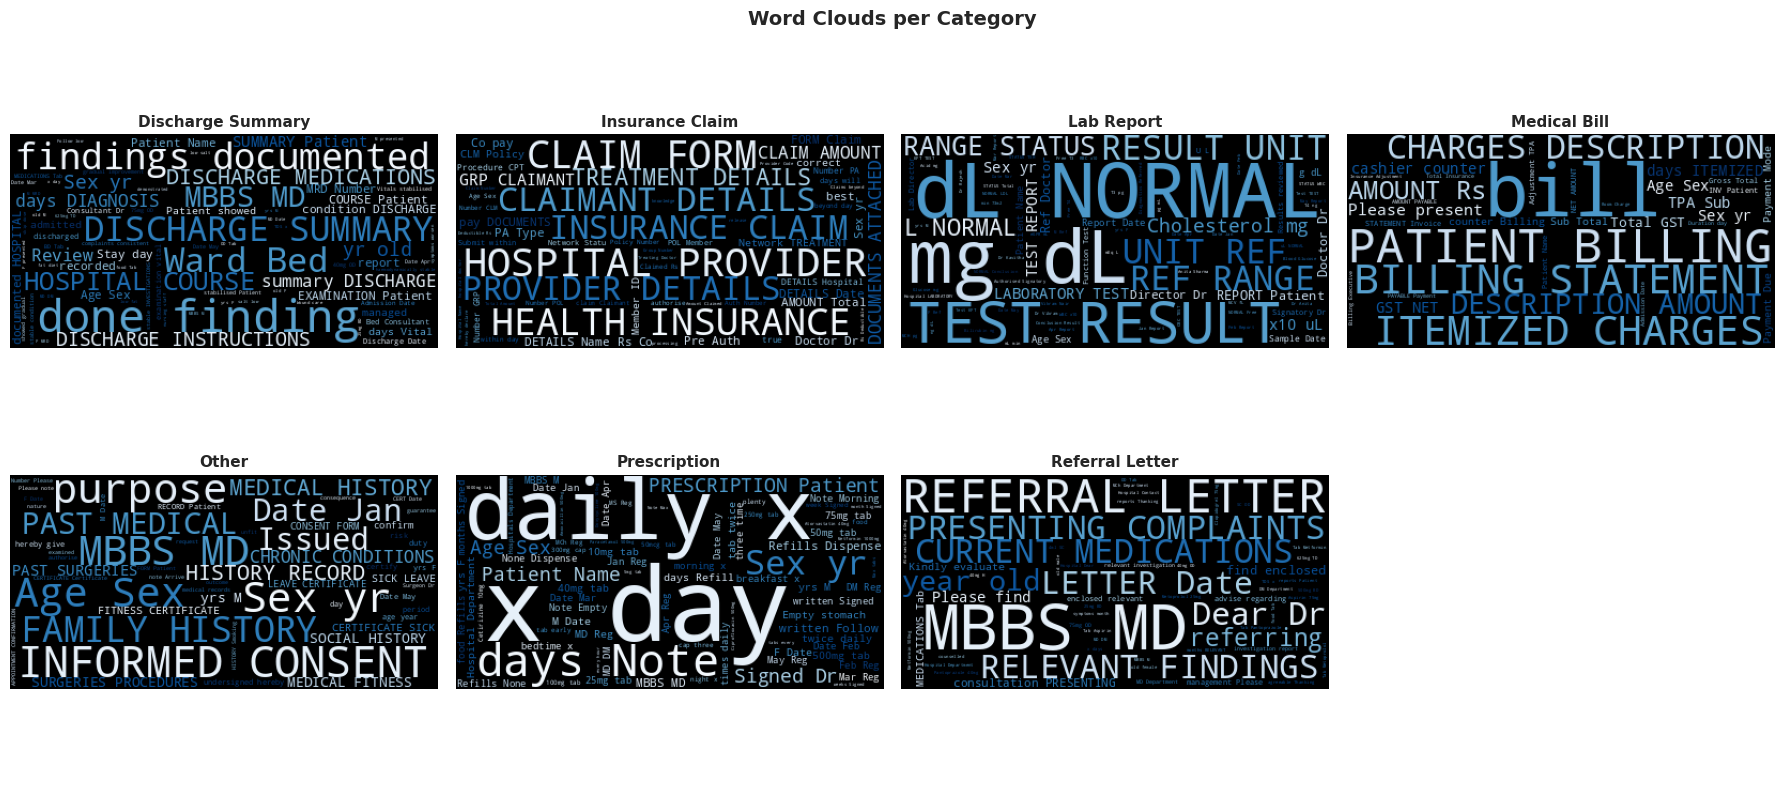

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

categories = sorted(data['label'].unique())
for i, cat in enumerate(categories):
    subset_text = " ".join(data[data['label'] == cat]['text'].values)
    wc = WordCloud(
        width=400, height=200,
        background_color='black',
        colormap='Blues',
        random_state=42,
        max_words=80
    ).generate(subset_text)
    axes[i].imshow(wc)
    axes[i].axis('off')
    axes[i].set_title(cat.replace('_', ' ').title(), fontsize=11, fontweight='bold')

# hide unused subplot
for j in range(len(categories), len(axes)):
    axes[j].axis('off')

plt.suptitle("Word Clouds per Category", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.8 Top TF-IDF Terms per Category

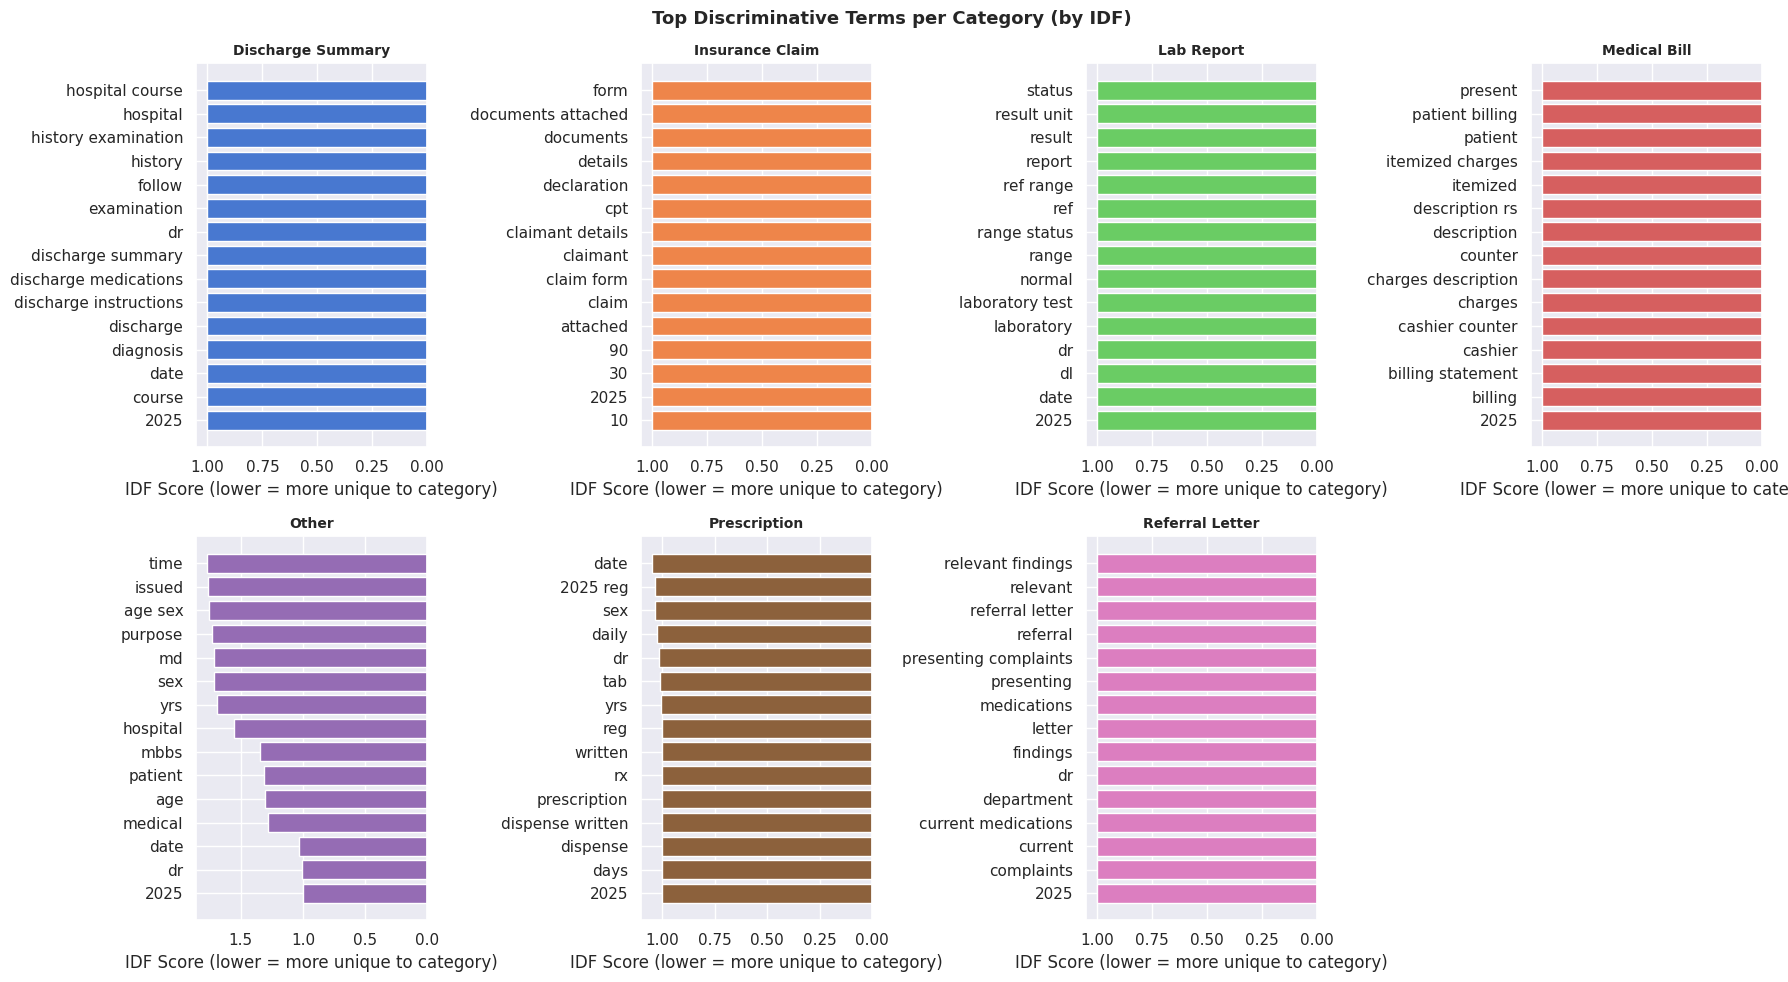

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer as _TFIDF

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    subset = data[data['label'] == cat]['text'].values
    tfidf  = _TFIDF(max_features=1000, stop_words='english', ngram_range=(1, 2))
    tfidf.fit(subset)
    scores   = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
    # lower idf = more important (appears in more docs)
    top_terms = sorted(scores, key=scores.get)[:15]
    top_scores = [scores[t] for t in top_terms]

    axes[i].barh(top_terms, top_scores, color=sns.color_palette("muted")[i % 8])
    axes[i].set_title(cat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel("IDF Score (lower = more unique to category)")
    axes[i].invert_xaxis()

for j in range(len(categories), len(axes)):
    axes[j].axis('off')

plt.suptitle("Top Discriminative Terms per Category (by IDF)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.9 Correlation: line_count vs word_count

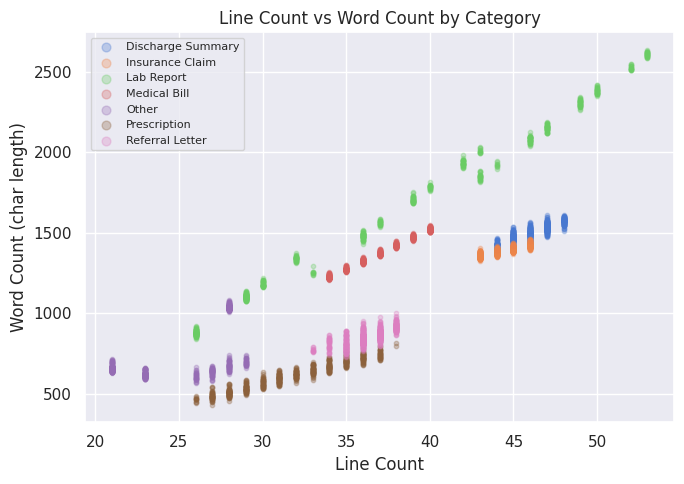

Pearson correlation (line_count, word_count): 0.801


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for cat in categories:
    subset = data[data['label'] == cat]
    ax.scatter(subset['line_count'], subset['word_count'],
               label=cat.replace('_', ' ').title(), alpha=0.3, s=10)
ax.set_xlabel("Line Count")
ax.set_ylabel("Word Count (char length)")
ax.set_title("Line Count vs Word Count by Category")
ax.legend(markerscale=2, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

print(f"Pearson correlation (line_count, word_count): {data['line_count'].corr(data['word_count']):.3f}")


## 4. Prepare Features & Labels

In [12]:
X = data[['text', 'line_count', 'word_count', 'file_format']].copy()
y = data['label'].copy()

print(f"X shape : {X.shape}")
print(f"y distribution:\n{y.value_counts()}")


X shape : (4900, 4)
y distribution:
label
other                700
lab_report           700
referral_letter      700
prescription         700
discharge_summary    700
insurance_claim      700
medical_bill         700
Name: count, dtype: int64


## 5. Label Encoding

In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded:", list(range(len(le.classes_))))


Classes: ['discharge_summary', 'insurance_claim', 'lab_report', 'medical_bill', 'other', 'prescription', 'referral_letter']
Encoded: [0, 1, 2, 3, 4, 5, 6]


## 6. Train / Validation Split

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    stratify=y_encoded,
    test_size=0.2,
    random_state=42
)

print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"\nTrain class distribution: {Counter(y_train)}")
print(f"Val   class distribution: {Counter(y_val)}")


Train : 3920
Val   : 980

Train class distribution: Counter({np.int64(0): 560, np.int64(4): 560, np.int64(6): 560, np.int64(3): 560, np.int64(5): 560, np.int64(2): 560, np.int64(1): 560})
Val   class distribution: Counter({np.int64(3): 140, np.int64(5): 140, np.int64(4): 140, np.int64(2): 140, np.int64(0): 140, np.int64(6): 140, np.int64(1): 140})


## 7. Preprocessing Pipeline

In [15]:
# Common preprocessor used by SVM, LogReg, XGB
preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=10000,
             ngram_range=(1, 2),    # unigrams + bigrams
             min_df=2,              # drop terms appearing in < 2 docs
             max_df=0.95,           # drop terms appearing in > 95% of docs
             sublinear_tf=True,     # apply log(1+tf) scaling
         ),
         'text'),
        ('counts',
         StandardScaler(),
         ['line_count', 'word_count']),
        ('file_format',
         OneHotEncoder(handle_unknown='ignore'),
         ['file_format']),
    ],
    remainder='drop',
)

# Separate preprocessor for Naive Bayes (NB needs non-negative, no StandardScaler)
nb_preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=5000,
             ngram_range=(1, 2),
             min_df=2,
             max_df=0.95,
             sublinear_tf=True,
         ),
         'text'),
    ],
    remainder='drop',
)

print("Preprocessors defined.")


Preprocessors defined.


## 8. Define Models

In [16]:
svm_model = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000)

logreg_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    n_jobs=-1,
    C=1.0,
)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    device = 'cuda',
    n_jobs=-1,
    random_state=42,
)

nb_model = ComplementNB()

print("Models defined.")


Models defined.


## 9. Build Full Pipelines

In [17]:
svm_pipeline = Pipeline([('prep', preprocessor), ('model', svm_model)])
logreg_pipeline = Pipeline([('prep', preprocessor), ('model', logreg_model)])
xgb_pipeline = Pipeline([('prep', preprocessor), ('model', xgb_model)])
nb_pipeline = Pipeline([('prep', nb_preprocessor), ('model', nb_model)])

print("Pipelines ready.")


Pipelines ready.


## 10. Train All Models

In [18]:
print('Training SVM...')
svm_pipeline.fit(X_train, y_train)
print('Done.')

Training SVM...
Done.


In [19]:
print('Training Logistic Regression...')
logreg_pipeline.fit(X_train, y_train)
print('Done.')

Training Logistic Regression...
Done.


In [20]:
print('Training Naive Bayes...')
nb_pipeline.fit(X_train, y_train)
print('Done.')

Training Naive Bayes...
Done.


In [21]:
print('Training XGBoost...')
xgb_pipeline.fit(X_train, y_train)
print('Done.')

Training XGBoost...
Done.


## 11. Evaluate All Models

=== Validation Accuracy ===
  SVM                       1.0000
  Logistic Regression       1.0000
  Naive Bayes               1.0000
  XGBoost                   1.0000


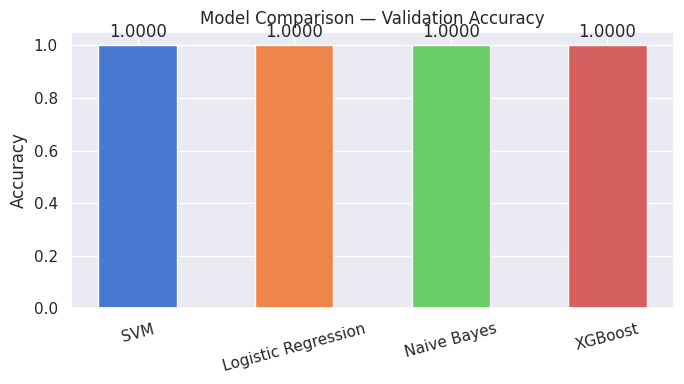

In [22]:
y_pred_svm    = svm_pipeline.predict(X_val)
y_pred_logreg = logreg_pipeline.predict(X_val)
y_pred_nb     = nb_pipeline.predict(X_val)
y_pred_xgb    = xgb_pipeline.predict(X_val)

results = {
    'SVM':                 accuracy_score(y_val, y_pred_svm),
    'Logistic Regression': accuracy_score(y_val, y_pred_logreg),
    'Naive Bayes':         accuracy_score(y_val, y_pred_nb),
    'XGBoost':             accuracy_score(y_val, y_pred_xgb),
}

print("=== Validation Accuracy ===")
for model_name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {model_name:<25} {acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results.keys(), results.values(),
              color=sns.color_palette("muted", len(results)), width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison — Validation Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 12. Detailed Evaluation — XGBoost

In [23]:
print("=== XGBoost Classification Report ===")
print(classification_report(y_val, y_pred_xgb, target_names=le.classes_))


=== XGBoost Classification Report ===
                   precision    recall  f1-score   support

discharge_summary       1.00      1.00      1.00       140
  insurance_claim       1.00      1.00      1.00       140
       lab_report       1.00      1.00      1.00       140
     medical_bill       1.00      1.00      1.00       140
            other       1.00      1.00      1.00       140
     prescription       1.00      1.00      1.00       140
  referral_letter       1.00      1.00      1.00       140

         accuracy                           1.00       980
        macro avg       1.00      1.00      1.00       980
     weighted avg       1.00      1.00      1.00       980



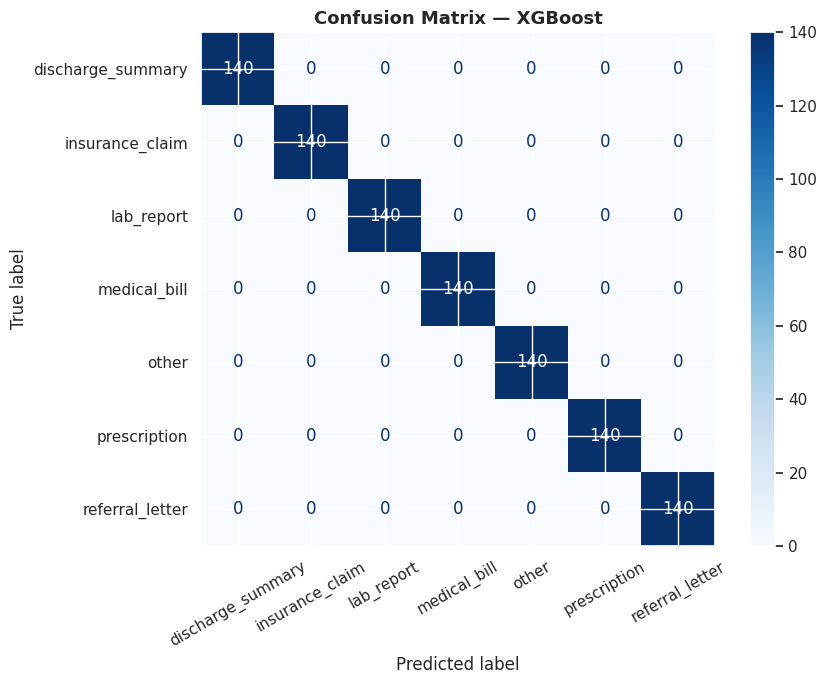

In [24]:
cm = confusion_matrix(y_val, y_pred_xgb)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title("Confusion Matrix — XGBoost", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 12.1 Per-class Precision / Recall / F1 bar chart

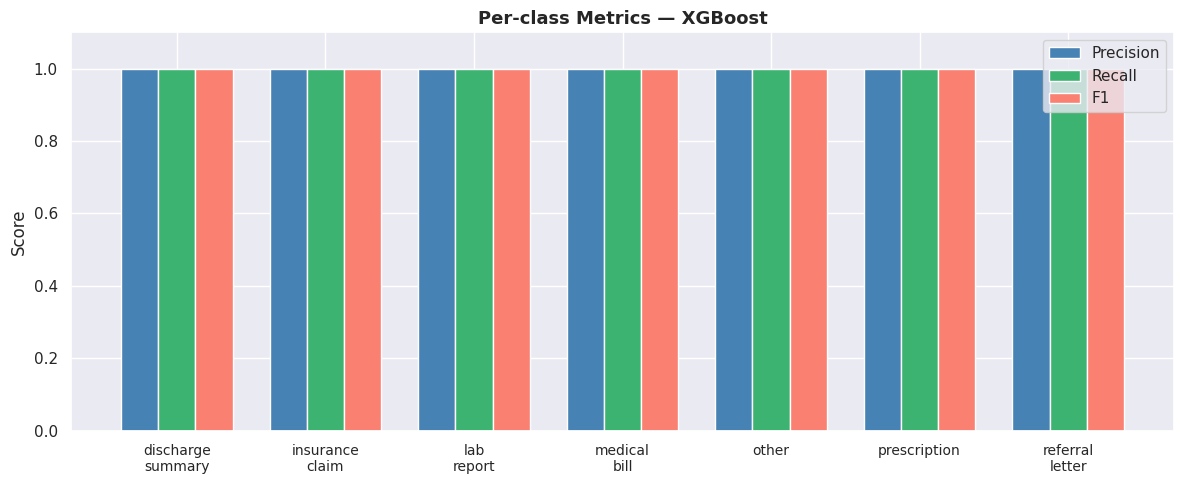

In [25]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_val, y_pred_xgb, labels=range(len(le.classes_))
)

x = np.arange(len(le.classes_))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x,         recall,    width, label='Recall',    color='mediumseagreen')
ax.bar(x + width, f1,        width, label='F1',        color='salmon')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in le.classes_], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-class Metrics — XGBoost", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 12.2 Cross-validation (XGBoost)

In [26]:
print("Running 5-fold cross-validation on XGBoost (this may take a few minutes)...")
cv_scores = cross_val_score(
    xgb_pipeline, X, y_encoded,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
)
print(f"CV Scores  : {cv_scores.round(4)}")
print(f"Mean ± Std : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Running 5-fold cross-validation on XGBoost (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:52:09] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:52:15] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

CV Scores  : [1. 1. 1. 1. 1.]
Mean ± Std : 1.0000 ± 0.0000


### 12.3 Feature importance — top TF-IDF tokens driving XGBoost

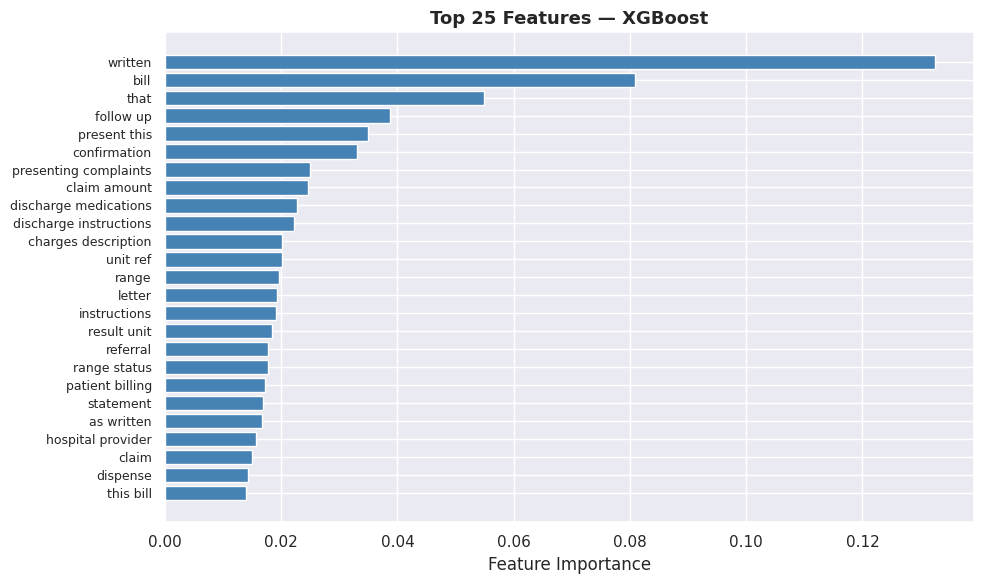

In [27]:
try:
    clf         = xgb_pipeline.named_steps['model']
    prep        = xgb_pipeline.named_steps['prep']
    importances = clf.feature_importances_

    # Get feature names from the ColumnTransformer
    tfidf_names  = prep.named_transformers_['text'].get_feature_names_out()
    scaler_names = np.array(['line_count', 'word_count'])
    ohe_names    = prep.named_transformers_['file_format'].get_feature_names_out()
    all_names    = np.concatenate([tfidf_names, scaler_names, ohe_names])

    top_n = 25
    top_idx   = np.argsort(importances)[::-1][:top_n]
    top_names = all_names[top_idx]
    top_vals  = importances[top_idx]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), top_vals[::-1], color='steelblue')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names[::-1], fontsize=9)
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top {top_n} Features — XGBoost", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Feature importance plot skipped: {e}")


## 13. Sanity Check on Realistic Text

In [28]:
# These texts are written to resemble real OCR output from real documents
# NOT the synthetic word-soup of the old dataset
sanity_cases = [
    {
        "text": "Apollo Hospitals Prescription\nPatient Name: Rohit Sharma  Age: 35  Date: 12-Jan-2025\nDoctor: Dr. Priya Mehta  MBBS MD  Reg No: MH12345\n\nRx\n1. Amoxicillin 500mg  - 1 tab twice daily x 7 days\n2. Pantoprazole 40mg  - 1 tab before breakfast x 7 days\n3. Paracetamol 500mg  - 1 tab as needed for fever\n\nRefills: 0\nDispense as written\n\nSigned: Dr. Priya Mehta",
        "file_format": "png", "expected": "prescription"
    },
    {
        "text": "Metropolis Healthcare Labs\nLab Report\nPatient: Sneha Reddy  Age: 28  Sample Date: 10-Jan-2025\n\nComplete Blood Count (CBC)\nWBC        6.5   x10^3/uL   Reference: 4.0-11.0\nRBC        4.8   x10^6/uL   Reference: 3.8-5.2\nHemoglobin 14.2  g/dL       Reference: 11.5-16.5\nPlatelets  250   x10^3/uL   Reference: 150-400\n\nLipid Panel\nTotal Cholesterol 185  mg/dL  Reference: <200   NORMAL\nLDL Cholesterol   110  mg/dL  Reference: <130   NORMAL\nHDL Cholesterol    52  mg/dL  Reference: >40    NORMAL\nTriglycerides     115  mg/dL  Reference: <150   NORMAL\n\nConclusion: All values within normal limits.",
        "file_format": "pdf", "expected": "lab_report"
    },
    {
        "text": "Max Super Speciality Hospital\nDischarge Summary\n\nPatient: Anita Singh  Age: 45  MRD: 2025001234\nAdmission Date: 05-Jan-2025  Discharge Date: 10-Jan-2025\nWard: Cardiology  Consultant: Dr. Ramesh Kumar\n\nDiagnosis: Unstable Angina\n\nHospital Course:\nPatient admitted with chest pain radiating to left arm. ECG showed ST changes. Troponin mildly elevated. Patient stabilised with IV nitrates and anticoagulation. Angiography performed showing 70% LAD stenosis. Medical management opted. Discharged in stable condition.\n\nDischarge Medications:\n- Aspirin 75mg OD\n- Atorvastatin 40mg HS\n- Metoprolol 25mg BD\n\nFollow up with cardiology in 2 weeks.\nDischarge instructions given. Patient counselled on diet and activity.",
        "file_format": "pdf", "expected": "discharge_summary"
    },
    {
        "text": "Fortis Hospital\nMedical Bill / Invoice\n\nInvoice No: INV-2025-00456\nPatient: Ravi Kumar  Date: 15-Jan-2025\nBilling Period: 08-Jan-2025 to 15-Jan-2025\n\nItemized Charges:\nConsultation Fee (Cardiology)      Rs. 1,500\nRoom Charges (7 days @ Rs. 3000)   Rs. 21,000\nNursing Charges                    Rs. 3,500\nOperation Theatre Charges          Rs. 25,000\nAnaesthesia Charges                Rs. 8,000\nLaboratory Tests                   Rs. 4,200\nMedications                        Rs. 2,800\nMiscellaneous                      Rs. 1,000\n\nGross Total                        Rs. 67,000\nInsurance Adjustment               Rs. 45,000\nNet Amount Due                     Rs. 22,000\n\nPlease pay at the billing counter. Thank you.",
        "file_format": "pdf", "expected": "medical_bill"
    },
    {
        "text": "United Health Insurance\nHealth Insurance Claim Form\n\nPolicy Number: UHI-987654-A\nMember ID: MEM12345  Group Number: GRP-456\nClaimant Name: Deepa Menon  Date of Birth: 15-Mar-1980\n\nDate of Service: 08-Jan-2025\nProvider: City Hospital  Provider Code: PRV789\nDiagnosis Code (ICD-10): J18.9 - Community Acquired Pneumonia\nProcedure Code (CPT): 99213 - Office Visit\nPre-Authorization Number: PA-2025-00123\n\nAmount Claimed: Rs. 45,000\nDocuments Attached: Discharge Summary, Lab Reports, Bills\n\nDeclaration: I hereby certify that the information given above is true and correct.\nSignature: Deepa Menon  Date: 20-Jan-2025",
        "file_format": "pdf", "expected": "insurance_claim"
    },
    {
        "text": "Manipal Hospital\nDepartment of General Medicine\n\nReferral Letter\nDate: 12-Jan-2025\n\nDear Dr. Suresh Patel,\nHead of Cardiology, AIIMS Delhi\n\nRe: Mr. Vikram Joshi, 58 years, M\n\nI am referring the above patient for a cardiology consultation. Mr. Joshi has been under my care for the past 3 months with complaints of recurrent palpitations, exertional dyspnoea and occasional chest discomfort. His recent ECG shows frequent PVCs and an echocardiogram suggests mild LV dysfunction with EF of 45%.\n\nKindly evaluate and advise regarding further management including possibility of EP study.\n\nAttached: ECG report, Echo report, Blood investigations\n\nThanks and regards,\nDr. Meena Iyer MBBS MD  Reg: KA98765",
        "file_format": "pdf", "expected": "referral_letter"
    },
    {
        "text": "City Medical Centre\nPatient Consent Form\n\nPatient Name: Arjun Nair  Date: 10-Jan-2025\n\nI, Arjun Nair, hereby provide my informed consent for the medical procedure recommended by my treating physician. I understand the nature, risks, and benefits of the proposed treatment. I have been given the opportunity to ask questions and all my queries have been answered to my satisfaction.\n\nI also consent to the use of my anonymised medical data for research and quality improvement purposes in accordance with applicable privacy laws.\n\nSignature: Arjun Nair\nWitness: Dr. Pooja Sharma\nDate: 10-Jan-2025",
        "file_format": "pdf", "expected": "other"
    },
]

print("=== Sanity Check on Real-Style Text ===\n")
correct = 0
for tc in sanity_cases:
    df = pd.DataFrame([{
        "text":        tc["text"],
        "line_count":  len([l for l in tc["text"].splitlines() if l.strip()]),
        "word_count":  len(tc["text"]),    # character count — matches training
        "file_format": tc["file_format"],
    }])
    proba    = xgb_pipeline.predict_proba(df)[0]
    pred_int = int(np.argmax(proba))
    pred_str = le.inverse_transform([pred_int])[0]
    conf     = proba[pred_int]
    ok       = pred_str == tc["expected"]
    if ok: correct += 1
    status   = "✓" if ok else "✗"
    print(f"  {status}  Expected: {tc['expected']:<22} Got: {pred_str:<22} ({conf:.1%})")

print(f"\n  {correct}/{len(sanity_cases)} correct on real-style text")


=== Sanity Check on Real-Style Text ===

  ✓  Expected: prescription           Got: prescription           (99.8%)
  ✗  Expected: lab_report             Got: other                  (99.5%)
  ✗  Expected: discharge_summary      Got: other                  (96.3%)
  ✗  Expected: medical_bill           Got: other                  (99.6%)
  ✓  Expected: insurance_claim        Got: insurance_claim        (98.7%)
  ✗  Expected: referral_letter        Got: other                  (96.7%)
  ✓  Expected: other                  Got: other                  (76.2%)

  3/7 correct on real-style text


## 14. Save Model

In [29]:
bundle = {
    "pipeline":      xgb_pipeline,
    "label_encoder": le,
}
joblib.dump(bundle, "model.pkl")
print("✓ model.pkl saved")
print(f"  Pipeline steps : {list(xgb_pipeline.named_steps.keys())}")
print(f"  Classes        : {list(le.classes_)}")


✓ model.pkl saved
  Pipeline steps : ['prep', 'model']
  Classes        : ['discharge_summary', 'insurance_claim', 'lab_report', 'medical_bill', 'other', 'prescription', 'referral_letter']


## Notes

- `model.pkl` is a dict bundle: `{"pipeline": sklearn.Pipeline, "label_encoder": LabelEncoder}`
- The backend loads it as: `obj = joblib.load("model.pkl")` then `obj["pipeline"]` and `obj["label_encoder"]`
- At inference time, the backend must compute features identically:
  - `word_count = len(text)` — **character count**, not word count
  - `line_count = len([l for l in text.splitlines() if l.strip()])` — non-empty OCR lines
  - `file_format` — lowercase extension without dot, e.g. `"pdf"`, `"png"`, `"jpg"`
